# Task 4: Movie Rating Prediction

**Internship:** Arch Technologies — Data Science Internship Program

**Objective:** Using a movie ratings dataset, build a model to predict how a user might rate a movie they haven't seen yet. Two complementary approaches are used and compared: **collaborative filtering** (matrix factorization on the user-item rating matrix) and a **regression model** (content/feature-based). Performance is evaluated with standard rating-prediction metrics.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Load the Dataset

The **MovieLens (ml-latest-small)** dataset is used — a standard benchmark dataset for rating-prediction and recommender-system tasks. It's loaded directly from a public source (`ratings.csv`: userId, movieId, rating, timestamp; `movies.csv`: movieId, title, genres), so the notebook runs end-to-end with no manual download.

In [2]:
ratings_url = "https://raw.githubusercontent.com/topspinj/tmls-2020-recommender-workshop/master/data/ratings.csv"
movies_url = "https://raw.githubusercontent.com/topspinj/tmls-2020-recommender-workshop/master/data/movies.csv"

ratings = pd.read_csv(ratings_url)
movies = pd.read_csv(movies_url)

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Unique users:", ratings["userId"].nunique(), " Unique movies:", ratings["movieId"].nunique())

ratings.head()


Ratings shape: (100836, 4)
Movies shape: (9742, 3)
Unique users: 610  Unique movies: 9724


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
movies.head()


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
df = ratings.merge(movies, on="movieId", how="left")
df["year"] = df["title"].str.extract(r"\((\d{4})\)").astype(float)
df.head()


,userId,movieId,rating,timestamp,title,genres,year
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,1995.0
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,1995.0
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995.0
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995.0


## 3. Exploratory Data Analysis (EDA)

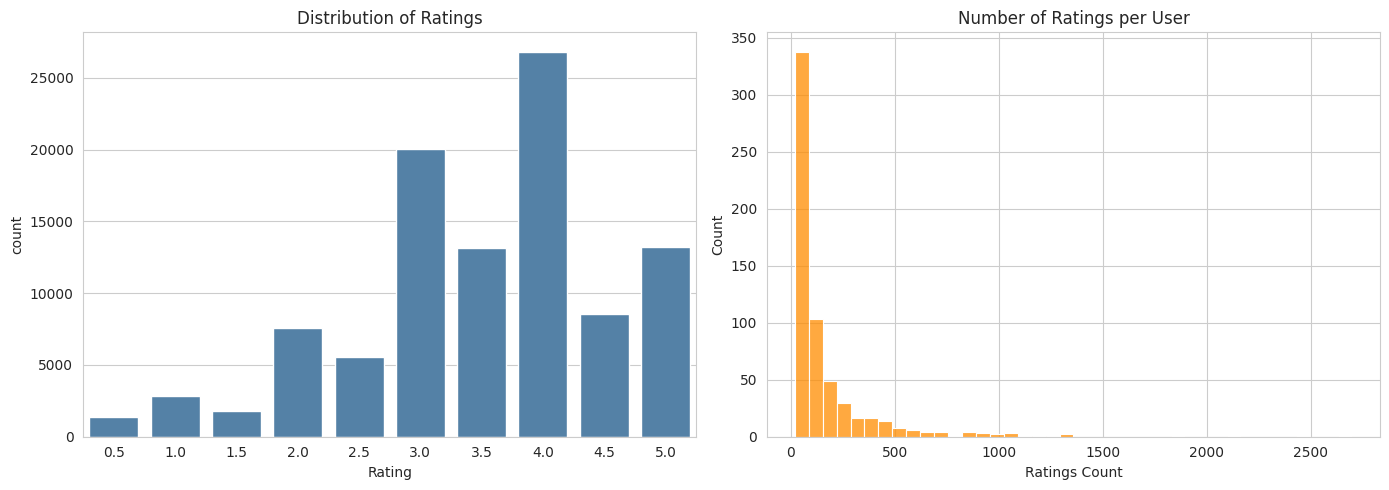

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="rating", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Ratings")
axes[0].set_xlabel("Rating")

ratings_per_user = ratings.groupby("userId").size()
sns.histplot(ratings_per_user, bins=40, ax=axes[1], color="darkorange")
axes[1].set_title("Number of Ratings per User")
axes[1].set_xlabel("Ratings Count")

plt.tight_layout()
plt.show()


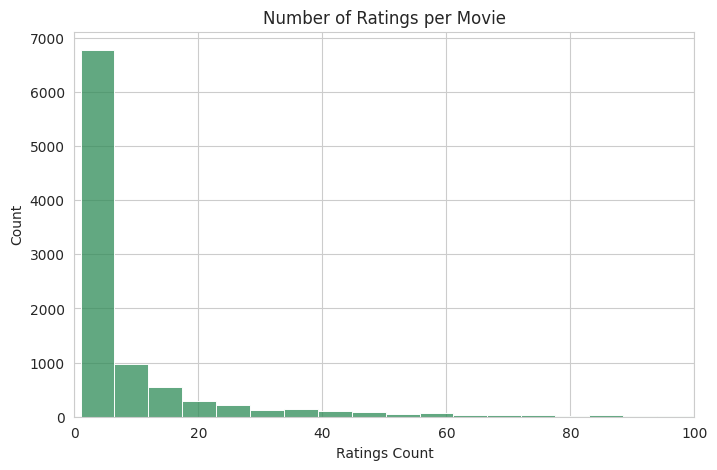

Median ratings per movie: 3
Movies with only 1 rating: 3446 out of 9724


In [6]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(8, 5))
sns.histplot(ratings_per_movie, bins=60, color="seagreen")
plt.title("Number of Ratings per Movie")
plt.xlabel("Ratings Count")
plt.xlim(0, 100)
plt.show()

print(f"Median ratings per movie: {ratings_per_movie.median():.0f}")
print(f"Movies with only 1 rating: {(ratings_per_movie == 1).sum()} out of {len(ratings_per_movie)}")


In [7]:
top_movies = (
    df.groupby("title")
    .agg(avg_rating=("rating", "mean"), num_ratings=("rating", "count"))
    .query("num_ratings >= 50")
    .sort_values("avg_rating", ascending=False)
    .head(10)
)
top_movies


,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


## 4. Data Pre-processing

Steps:
1. Split the ratings into **train (80%)** and **test (20%)** sets at the individual rating level.
2. Build the **user-item ratings matrix** (rows = users, columns = movies) from the training set only, so no test information leaks into the model.
3. For the collaborative-filtering model: mean-center each user's ratings (subtract that user's average rating) before factorizing, which corrects for users who tend to rate everything higher or lower than average.
4. For the regression model: engineer features (user average rating, movie average rating, global average, movie release year, one-hot encoded genres) computed only from the training data.


In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train size:", train_df.shape, " Test size:", test_df.shape)


Train size: (80668, 7)  Test size: (20168, 7)


In [9]:
user_ids = np.sort(train_df["userId"].unique())
movie_ids = np.sort(train_df["movieId"].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}

n_users, n_movies = len(user_ids), len(movie_ids)
print(f"Training matrix will be {n_users} users x {n_movies} movies")

row = train_df["userId"].map(user_to_idx).values
col = train_df["movieId"].map(movie_to_idx).values
vals = train_df["rating"].values

user_item_matrix = csr_matrix((vals, (row, col)), shape=(n_users, n_movies))


Training matrix will be 610 users x 8983 movies


## 5. Model 1: Collaborative Filtering (Matrix Factorization / SVD)

In [10]:
# Mean-center each user's ratings (only over movies they actually rated)
user_item_dense = user_item_matrix.toarray()
mask = user_item_dense != 0

user_means = np.array([
    user_item_dense[i, mask[i]].mean() if mask[i].any() else 0.0
    for i in range(n_users)
])

centered_matrix = np.where(mask, user_item_dense - user_means[:, None], 0.0)

N_COMPONENTS = 30
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
user_factors = svd.fit_transform(centered_matrix)
movie_factors = svd.components_

predicted_matrix = user_factors.dot(movie_factors) + user_means[:, None]
predicted_matrix = np.clip(predicted_matrix, 0.5, 5.0)

print("Predicted rating matrix shape:", predicted_matrix.shape)
print(f"Explained variance ratio (top {N_COMPONENTS} components): {svd.explained_variance_ratio_.sum():.3f}")


Predicted rating matrix shape: (610, 8983)
Explained variance ratio (top 30 components): 0.367


In [11]:
def cf_predict(user_id, movie_id):
    """Predict a rating using the matrix-factorization model. Returns None for cold-start
    users/movies not seen during training."""
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return None
    return predicted_matrix[user_to_idx[user_id], movie_to_idx[movie_id]]

cf_test = test_df.copy()
cf_test["cf_pred"] = cf_test.apply(lambda r: cf_predict(r["userId"], r["movieId"]), axis=1)

coverage = cf_test["cf_pred"].notna().mean()
print(f"Coverage (test rows with a known user & movie): {coverage:.1%}")

cf_eval = cf_test.dropna(subset=["cf_pred"])
cf_mae = mean_absolute_error(cf_eval["rating"], cf_eval["cf_pred"])
cf_rmse = np.sqrt(mean_squared_error(cf_eval["rating"], cf_eval["cf_pred"]))

print(f"Collaborative Filtering (SVD) -> MAE: {cf_mae:.3f}, RMSE: {cf_rmse:.3f}")


Coverage (test rows with a known user & movie): 96.0%
Collaborative Filtering (SVD) -> MAE: 0.713, RMSE: 0.924


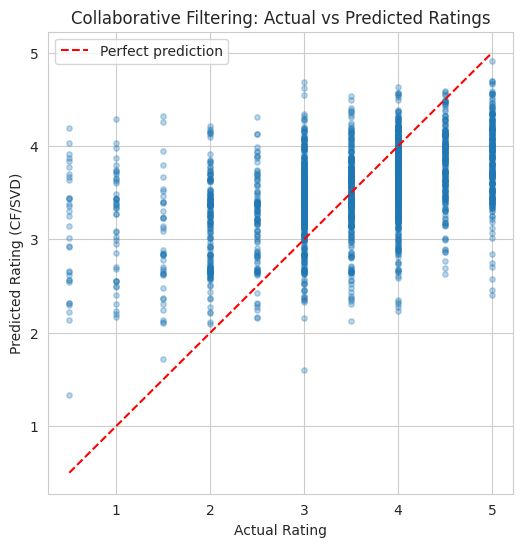

In [12]:
plt.figure(figsize=(6, 6))
sample = cf_eval.sample(min(2000, len(cf_eval)), random_state=42)
plt.scatter(sample["rating"], sample["cf_pred"], alpha=0.3, s=15)
plt.plot([0.5, 5], [0.5, 5], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating (CF/SVD)")
plt.title("Collaborative Filtering: Actual vs Predicted Ratings")
plt.legend()
plt.show()


## 6. Model 2: Regression Model (Content/Feature-Based)

In [13]:
global_avg = train_df["rating"].mean()

user_avg = train_df.groupby("userId")["rating"].mean().rename("user_avg_rating")
movie_avg = train_df.groupby("movieId")["rating"].mean().rename("movie_avg_rating")
movie_count = train_df.groupby("movieId")["rating"].count().rename("movie_rating_count")

def build_features(frame):
    feat = frame.merge(user_avg, on="userId", how="left")
    feat = feat.merge(movie_avg, on="movieId", how="left")
    feat = feat.merge(movie_count, on="movieId", how="left")
    feat["user_avg_rating"] = feat["user_avg_rating"].fillna(global_avg)
    feat["movie_avg_rating"] = feat["movie_avg_rating"].fillna(global_avg)
    feat["movie_rating_count"] = feat["movie_rating_count"].fillna(0)
    feat["year"] = feat["year"].fillna(feat["year"].median())
    return feat

train_feat = build_features(train_df)
test_feat = build_features(test_df)

# One-hot encode genres (top genres only, to keep the feature space compact)
all_genres = set(g for genre_str in movies["genres"] for g in genre_str.split("|"))
all_genres.discard("(no genres listed)")

for genre in sorted(all_genres):
    train_feat[f"genre_{genre}"] = train_feat["genres"].str.contains(genre, regex=False).astype(int)
    test_feat[f"genre_{genre}"] = test_feat["genres"].str.contains(genre, regex=False).astype(int)

feature_cols = ["user_avg_rating", "movie_avg_rating", "movie_rating_count", "year"] + \
               [f"genre_{g}" for g in sorted(all_genres)]

X_train_reg, y_train_reg = train_feat[feature_cols], train_feat["rating"]
X_test_reg, y_test_reg = test_feat[feature_cols], test_feat["rating"]

print("Number of features:", len(feature_cols))
X_train_reg.head()


Number of features: 23


,user_avg_rating,movie_avg_rating,movie_rating_count,year,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,3.227273,3.321429,14,2004.0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
1,4.039683,4.250000,4,2009.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3.407311,3.628049,82,1984.0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3.683429,3.509434,53,1989.0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
4,3.424863,3.192308,26,1979.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    preds = np.clip(model.predict(X_test_reg), 0.5, 5.0)
    reg_results[name] = {
        "model": model,
        "preds": preds,
        "mae": mean_absolute_error(y_test_reg, preds),
        "rmse": np.sqrt(mean_squared_error(y_test_reg, preds)),
        "r2": r2_score(y_test_reg, preds),
    }
    print(f"{name} -> MAE: {reg_results[name]['mae']:.3f}, "
          f"RMSE: {reg_results[name]['rmse']:.3f}, R2: {reg_results[name]['r2']:.3f}")


Linear Regression -> MAE: 0.686, RMSE: 0.898, R2: 0.268


Random Forest Regressor -> MAE: 0.682, RMSE: 0.897, R2: 0.268


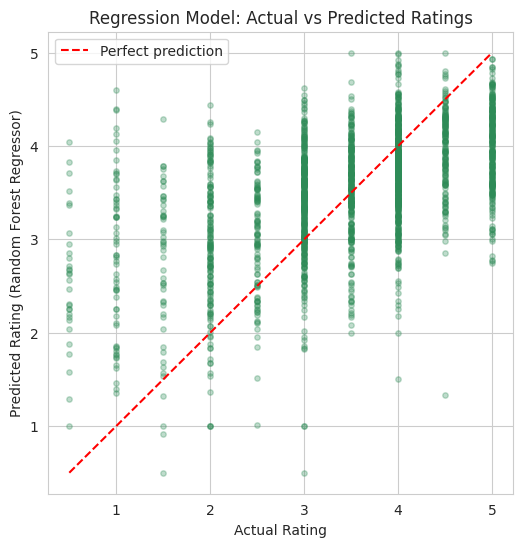

In [15]:
best_reg_name = min(reg_results, key=lambda k: reg_results[k]["rmse"])
best_reg_preds = reg_results[best_reg_name]["preds"]

plt.figure(figsize=(6, 6))
sample_idx = np.random.RandomState(42).choice(len(y_test_reg), size=min(2000, len(y_test_reg)), replace=False)
plt.scatter(y_test_reg.values[sample_idx], best_reg_preds[sample_idx], alpha=0.3, s=15, color="seagreen")
plt.plot([0.5, 5], [0.5, 5], color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Rating")
plt.ylabel(f"Predicted Rating ({best_reg_name})")
plt.title(f"Regression Model: Actual vs Predicted Ratings")
plt.legend()
plt.show()


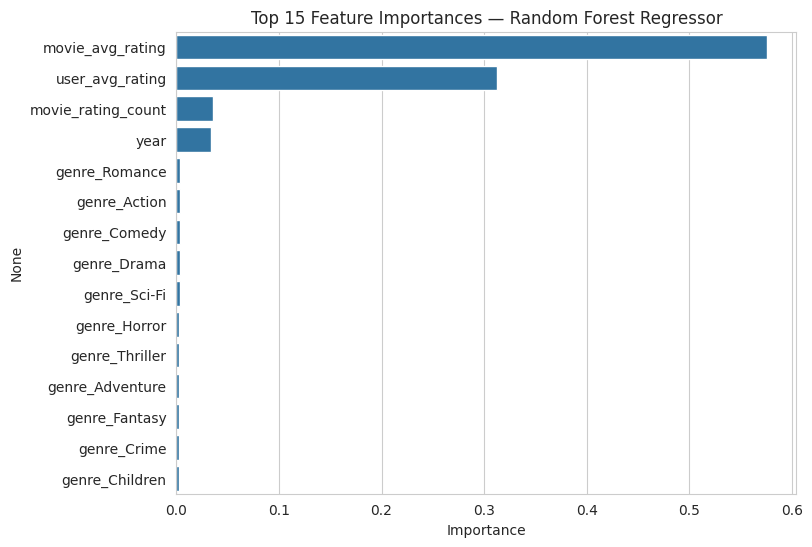

In [16]:
if best_reg_name == "Random Forest Regressor":
    importances = pd.Series(
        reg_results[best_reg_name]["model"].feature_importances_, index=feature_cols
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Top 15 Feature Importances — {best_reg_name}")
    plt.xlabel("Importance")
    plt.show()


## 7. Model Comparison

In [17]:
comparison = pd.DataFrame({
    "Model": ["Collaborative Filtering (SVD)"] + list(reg_results.keys()),
    "MAE": [cf_mae] + [r["mae"] for r in reg_results.values()],
    "RMSE": [cf_rmse] + [r["rmse"] for r in reg_results.values()],
}).set_index("Model")

comparison.sort_values("RMSE")


,MAE,RMSE
Model,,
Random Forest Regressor,0.682327,0.897066
Linear Regression,0.686366,0.897550
Collaborative Filtering (SVD),0.713149,0.923873


## 8. Example: Predicting a Rating for an Unseen Movie

In [18]:
sample_user = int(user_ids[0])
watched = set(train_df.loc[train_df["userId"] == sample_user, "movieId"])
unwatched_candidates = [m for m in movie_ids if m not in watched][:5]

print(f"Predicted ratings for user {sample_user} on movies they haven't rated yet:\n")
for movie_id in unwatched_candidates:
    title = movies.loc[movies["movieId"] == movie_id, "title"].values[0]
    cf_score = cf_predict(sample_user, movie_id)

    feat_row = build_features(pd.DataFrame({
        "userId": [sample_user], "movieId": [movie_id],
        "genres": [movies.loc[movies["movieId"] == movie_id, "genres"].values[0]],
        "year": [df.loc[df["movieId"] == movie_id, "year"].values[0] if (df["movieId"] == movie_id).any() else np.nan],
    }))
    for genre in sorted(all_genres):
        feat_row[f"genre_{genre}"] = feat_row["genres"].str.contains(genre, regex=False).astype(int)
    reg_score = reg_results[best_reg_name]["model"].predict(feat_row[feature_cols])[0]

    print(f"  {title:50s} | CF (SVD): {cf_score:.2f}  |  {best_reg_name}: {reg_score:.2f}")


Predicted ratings for user 1 on movies they haven't rated yet:

  Jumanji (1995)                                     | CF (SVD): 4.29  |  Random Forest Regressor: 4.04
  Waiting to Exhale (1995)                           | CF (SVD): 4.32  |  Random Forest Regressor: 3.03
  Father of the Bride Part II (1995)                 | CF (SVD): 4.30  |  Random Forest Regressor: 3.85
  Sabrina (1995)                                     | CF (SVD): 4.26  |  Random Forest Regressor: 3.89
  Tom and Huck (1995)                                | CF (SVD): 4.33  |  Random Forest Regressor: 3.80


## 9. Conclusion

- **Collaborative filtering** (mean-centered matrix factorization / SVD on the user-item ratings matrix) learns purely from the *pattern of who rated what how*, without needing any movie content information. It works best when a user and movie both have enough ratings in the training data — new users or movies are a "cold start" problem, reflected in the coverage metric above.
- The **regression model**, using engineered features (user average rating, movie average rating, popularity, release year, and genres), can still make a reasonable prediction even for movies it has partial information about, and its feature importances reveal that a user's own average rating and a movie's average rating are by far the strongest predictors — genres and release year add smaller, complementary signal.
- Comparing MAE/RMSE side by side shows the trade-off between the two families of approaches: collaborative filtering typically captures nuanced person-to-person taste patterns better, while the regression model is more robust to sparser data and easier to explain.
- In production recommender systems, these two approaches are often **combined** (a hybrid model) to get the benefits of both.

**Possible next steps:** tune the number of SVD latent factors, try item-based collaborative filtering as an additional comparison, incorporate richer content features (cast, director, tags), and evaluate with ranking-based metrics (e.g. Precision@K) in addition to rating-error metrics.
